In [57]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, r2_score, accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [6]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

<h1>UNDERSTANDING THE DATA</h1>

In [7]:
train.head(5)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [8]:
test.head(5)


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [9]:
submission.head(5)

,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,at-risk


In [10]:
train.head(3)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male


In [11]:
train['health_condition'].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [13]:
(train.isnull().sum() /len(train) )*100

id                          0.000000
health_condition            0.000000
sleep_duration             11.012943
heart_rate                  1.135073
bmi                         2.013946
calorie_expenditure         7.658878
step_count                  2.016554
exercise_duration           1.000017
water_intake                6.300211
diet_type                   1.000017
stress_level               12.000064
sleep_quality               8.452690
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
dtype: float64

In [14]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       295753 non-null  int64  
 1   sleep_duration           263182 non-null  float64
 2   heart_rate               292396 non-null  float64
 3   bmi                      289797 non-null  float64
 4   calorie_expenditure      273101 non-null  float64
 5   step_count               289789 non-null  float64
 6   exercise_duration        292795 non-null  float64
 7   water_intake             277120 non-null  float64
 8   diet_type                292795 non-null  str    
 9   stress_level             260263 non-null  str    
 10  sleep_quality            270754 non-null  str    
 11  physical_activity_level  280058 non-null  str    
 12  smoking_alcohol          283504 non-null  str    
 13  gender                   286593 non-null  str    
dtypes: float64(7), 

In [15]:
(test.isnull().sum() /len(test) )* 100

id                          0.000000
sleep_duration             11.012906
heart_rate                  1.135069
bmi                         2.013843
calorie_expenditure         7.659094
step_count                  2.016548
exercise_duration           1.000159
water_intake                6.300190
diet_type                   1.000159
stress_level               11.999878
sleep_quality               8.452662
physical_activity_level     5.306793
smoking_alcohol             4.141632
gender                      3.097179
dtype: float64

<h1>CLEANING THE DATA</h1>

In [16]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

<h4>REPLACE WITH MEAN<h4>

In [17]:
imputer = SimpleImputer(strategy='mean')

In [18]:
train[['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']] =imputer.fit_transform(train[['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']])

In [19]:
test[['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']] = imputer.transform(test[['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']])

<h5>TO CHECK IF IT WORKED</h5>

In [20]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration                 0
heart_rate                     0
bmi                            0
calorie_expenditure            0
step_count                     0
exercise_duration              0
water_intake                   0
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [21]:
test.isnull().sum()

id                             0
sleep_duration                 0
heart_rate                     0
bmi                            0
calorie_expenditure            0
step_count                     0
exercise_duration              0
water_intake                   0
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

In [22]:
train.dtypes

id                           int64
health_condition               str
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
dtype: object

In [23]:
list1 = train[['diet_type','stress_level','sleep_quality','physical_activity_level','smoking_alcohol','gender']]

for x in list1:
    #print(f'{x}')
    print(train[x].value_counts())
    print('\n')

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64


stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64


sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64


physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64


smoking_alcohol
yes           223730
no            219791
occasional    217985
Name: count, dtype: int64


gender
male      237756
female    224016
other     206943
Name: count, dtype: int64




In [24]:
categorical_data = [
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'smoking_alcohol',
    'gender'
]

In [25]:
dummies = pd.get_dummies(train[categorical_data],dtype=int)

In [26]:
train = pd.concat([train.drop(columns = categorical_data), dummies],axis = 1)

In [27]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 690088 non-null  int64  
 1   health_condition                   690088 non-null  str    
 2   sleep_duration                     690088 non-null  float64
 3   heart_rate                         690088 non-null  float64
 4   bmi                                690088 non-null  float64
 5   calorie_expenditure                690088 non-null  float64
 6   step_count                         690088 non-null  float64
 7   exercise_duration                  690088 non-null  float64
 8   water_intake                       690088 non-null  float64
 9   diet_type_balanced                 690088 non-null  int64  
 10  diet_type_non-veg                  690088 non-null  int64  
 11  diet_type_veg                      690088 non-null

In [28]:
dummies_test = pd.get_dummies(test[categorical_data],dtype=int)

In [29]:
test = pd.concat([test.drop(columns = categorical_data),dummies_test ],axis = 1)

In [30]:
train.head(3)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,...,sleep_quality_poor,physical_activity_level_active,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,...,0,0,0,1,0,0,1,1,0,0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,...,0,0,1,0,0,0,1,0,0,1
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,...,1,1,0,0,0,0,1,0,1,0


In [31]:
train.head(3)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,...,sleep_quality_poor,physical_activity_level_active,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,...,0,0,0,1,0,0,1,1,0,0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,...,0,0,1,0,0,0,1,0,0,1
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,...,1,1,0,0,0,0,1,0,1,0


In [32]:
train.isnull().sum()

id                                   0
health_condition                     0
sleep_duration                       0
heart_rate                           0
bmi                                  0
calorie_expenditure                  0
step_count                           0
exercise_duration                    0
water_intake                         0
diet_type_balanced                   0
diet_type_non-veg                    0
diet_type_veg                        0
stress_level_high                    0
stress_level_low                     0
stress_level_medium                  0
sleep_quality_average                0
sleep_quality_good                   0
sleep_quality_poor                   0
physical_activity_level_active       0
physical_activity_level_moderate     0
physical_activity_level_sedentary    0
smoking_alcohol_no                   0
smoking_alcohol_occasional           0
smoking_alcohol_yes                  0
gender_female                        0
gender_male              

<h1>EDA<h1>

<Axes: xlabel='health_condition', ylabel='gender_female'>

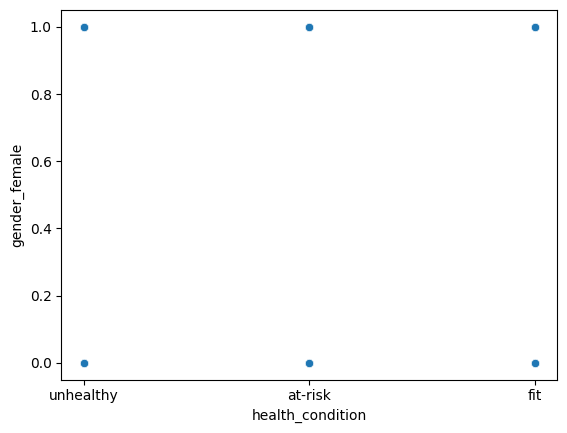

In [33]:
sns.scatterplot(x = 'health_condition',y='gender_female',data = train)

<Axes: xlabel='health_condition', ylabel='gender_female'>

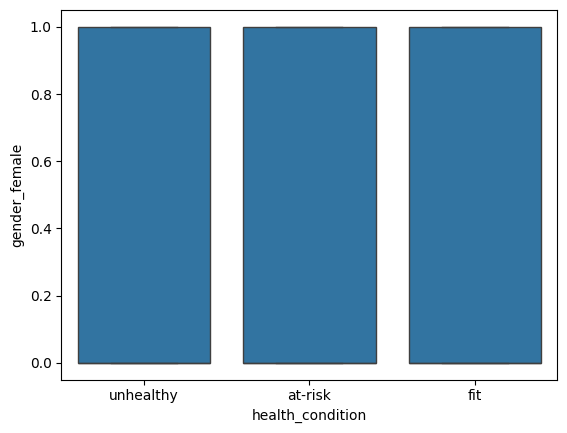

In [34]:
sns.boxplot(x = 'health_condition',y='gender_female',data = train)

<Axes: xlabel='health_condition', ylabel='gender_male'>

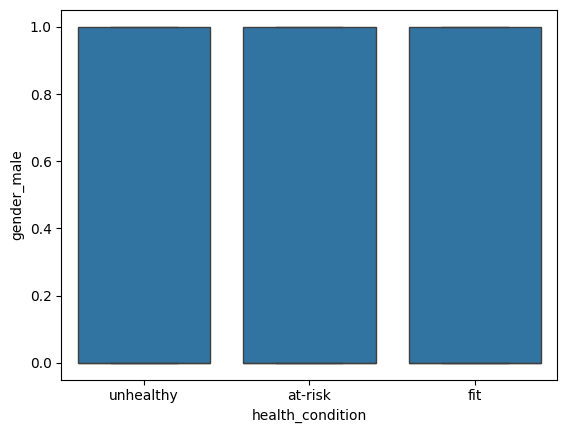

In [35]:
sns.boxplot(x = 'health_condition',y='gender_male',data = train)

<Axes: xlabel='health_condition', ylabel='smoking_alcohol_no'>

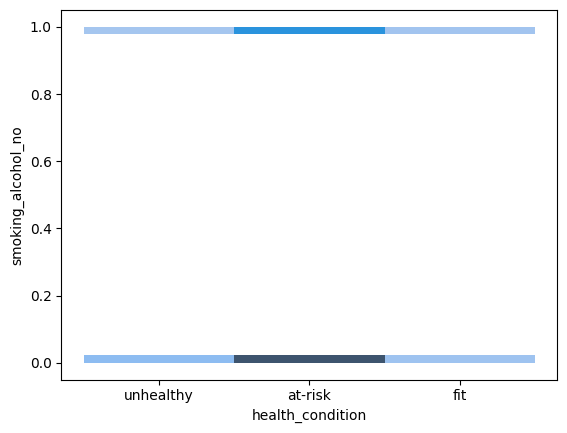

In [36]:
sns.histplot(x ='health_condition', y='smoking_alcohol_no',data = train )

<h4>SPLITTING AND SCALLING DATA</h4>

In [37]:
x_train = train.drop(columns=['health_condition'])
y_train = train['health_condition']

In [38]:
scalar = StandardScaler()

In [39]:
x_train = scalar.fit_transform(x_train)

In [40]:
label = LabelEncoder()

In [41]:
y_train  = label.fit_transform(y_train)

In [42]:
#y_train = scalar.fit_transform(y_train)

<h1>MODEL SELECTION</h1>

In [43]:
parameters = {
    'max_depth':[5,10,15,20],
    'max_features':[10,15,20]
}
search_decission = GridSearchCV(
    DecisionTreeClassifier(),
    parameters,
    cv = 3
)

In [45]:
search_decission.fit(x_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [10, 15, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [46]:
print(search_decission.best_estimator_)

DecisionTreeClassifier(max_depth=5, max_features=10)


In [47]:
print(search_decission.best_params_)

{'max_depth': 5, 'max_features': 10}


In [48]:
model_decission_tree = DecisionTreeClassifier(max_depth=5,max_features=20)

In [49]:
model_decission_tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [50]:
y_hat_decission = model_decission_tree.predict(x_train)

In [51]:
print(y_hat_decission[0:5])

[2 0 2 2 0]


In [52]:
print('F1_SCORE: ',f1_score(y_train,y_hat_decission,average='weighted'))
print('accuracy_score: ',accuracy_score(y_train,y_hat_decission))

print('balanced_accuracy_score: ',balanced_accuracy_score(y_train,y_hat_decission))

F1_SCORE:  0.9598264742760771
accuracy_score:  0.9617613985462724
balanced_accuracy_score:  0.8410639678685891


In [53]:
confusion_matrix(y_train,y_hat_decission)

array([[589660,   2701,    200],
       [  8246,  31466,     91],
       [ 15057,     93,  42574]])

In [58]:
score_tree =cross_val_score(
    model_decission_tree,
    x_train,
    y_train,
    cv =5
)

In [59]:
print(score_tree)
print(score_tree.mean())

[0.48122709 0.96281644 0.96266429 0.96280168 0.96243216]
0.8663883337446535


<h3> SVC </h3>

In [60]:
parameters_svc = {
    'kernel' : ['rbf','poly'],
    'C':[10,20,50,100],
    'gamma':[0.01,0.1,1]
}

In [61]:
grid_svc = GridSearchCV(
    SVC(),
    parameters_svc,
    cv =3
)


In [ ]:
grid_svc.fit(x_train,y_train)

In [ ]:
print(grid_svc.best_params_)

In [ ]:
model_SVC = SVC(kernel = ' ',C = '',gamma = '')

In [ ]:
model_SVC.fit(x_train,y_train)

In [ ]:
y_hat_svc = model_SVC.predict(x_train)

In [ ]:
print(y_hat_svc[0:5])

In [ ]:
print('F1_SCORE: ',f1_score(y_train,y_hat_svc,average='weighted'))
print('accuracy_score: ',accuracy_score(y_train,y_hat_svc))

print('balanced_accuracy_score: ',balanced_accuracy_score(y_train,y_hat_svc))

<h3>RANDOM FOREST CLASSIFIER </h3>

In [ ]:
parameters_random_forest = {
    'max_depth':[8,12,15,20],
    'max_features':[2,3,4],
    'n_estimators':[100,150,250]
}

In [ ]:
grid_rfc = GridSearchCV(
    RandomForestClassifier(),
    parameters_random_forest,
    cv =3
)

In [ ]:
print(grid_rfc.best_estimator_)

In [ ]:
model_random_forest = RandomForestClassifier(max_depth=3,max_features=4,n_estimators=)

In [ ]:
model_random_forest.fit(x_train,y_train)

In [ ]:
y_hat_rfc = model_random_forest.predict(x_test)

In [ ]:
print('F1_SCORE: ',f1_score(y_train,y_hat_rfc,average='weighted'))
print('accuracy_score: ',accuracy_score(y_train,y_hat_rfc))

print('balanced_accuracy_score: ',balanced_accuracy_score(y_train,y_hat_rfc))

In [ ]:
score_rfc = cross_val_score(
    model_random_forest,
    x_train,
    y_train,
    cv =5
)

In [ ]:
print(score_rfc)
print(score_rfc.mean())